# Performance objective:
Let:
- **TPR** = true positive rate (recall)  
- **FPR** = false positive rate  
- Positive rate **π = P(Y = 1)** (rate of fraud)  
- Negative rate **1 − π = P(Y = 0)** (rate of non-fraud)
- **C_R** = expected relative cost associated with manually reviewing a case flagged by the model
- **C_FN** = expected relative cost of a false negative (failing to detect fraud)

Then the population-normalized expected loss is:

E[Loss] = C_R · (TPR · π + FPR · (1 − π)) + C_FN · (1 − TPR) · π

Key modeling assumptions:
- After the model detects fraud, the case undergoes manual review.
- Manual review is treated as the ground-truth adjudication process (assumed to make the final decision for whether fraud occurred).
- Costs associated with manual review are approximately equal for false positives and true positives.
- Since this is a synthetic dataset, we do not have access to true values for C_R and C_FN. Thus, for the purposes of this hypothetical modeling scenario, we choose illustrative values for C_R and C_FN. We estimate the average cost of manual review plus associated operational and customer-friction costs to be approximately \$40–\$80 per reviewed account. We estimate the expected fraud loss per missed fraud case to be approximately \$2,000–\$5,000. This implies a plausible range for C_FN/C_R of roughly 25 to 125. For this investigation, we will adopt a balanced scenario using the midpoint of this range, with C_FN/C_R = 75. Therefore, we use C_R = 1 and C_FN = 75.

The final performance objective, which we will aim to minimize, is then:

<ins>**E[Loss] = (TPR · π + FPR · (1 − π)) + 75(1 − TPR) · π**</ins>

To simulate real-world effects of temporal instability/concept drift, our test dataset will consist of the final 2 months of data.

# Data Preprocessing:
- Train/test split: First 6 months for training, last 2 months for testing
- Drop the ‘month’ column.
- Drop the 'device_fraud_count' column. It is a constant-valued column (useless for prediction)
- One-hot encoding of categorical columns
- Add the "cat__housing_status_BEBCBB" feature, as informed by our analysis in Exploratory_Data_Analysis.ipynb.

In [2]:
import pandas as pd

df = pd.read_csv('Base.csv')

In [3]:
# data processing
mask = df["month"] <= 5
full_training_data = df[mask].sample(frac=1).reset_index(drop=True).drop('month',axis=1) # train on months 0 to 5. drop month as a feature
full_test_data = df[~mask].sample(frac=1).reset_index(drop=True).drop('month',axis=1) # test on months 6 and 7. drop month as a feature

# 'device_fraud_count' is literally a constant column. get rid of it.
full_training_data = full_training_data.drop('device_fraud_count',axis=1)
full_test_data = full_test_data.drop('device_fraud_count',axis=1)

print("Full training data # rows: " + str(full_training_data.shape[0]))
print("Full test data # rows: " + str(full_test_data.shape[0]))
print("Column list: " + str(full_training_data.columns))

Full training data # rows: 794989
Full test data # rows: 205011
Column list: Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w'],
      dtype='object')


In [4]:
# more data processing
y_train_full = full_training_data["fraud_bool"]
X_train_full = full_training_data.drop("fraud_bool",axis=1)
y_test_full = full_test_data["fraud_bool"]
X_test_full = full_test_data.drop("fraud_bool",axis=1)

# prevalence rate of y = 1 in the training set
pi = y_train_full.mean()

# make sure all numerical columns are actually stored numerically
y_train_full = y_train_full.astype(float)
y_test_full = y_test_full.astype(float)
for col in X_train_full.columns:
    converted = pd.to_numeric(X_train_full[col], errors='coerce')
    if converted.notna().sum() == X_train_full[col].notna().sum():
        X_train_full[col] = converted
for col in X_test_full.columns:
    converted = pd.to_numeric(X_test_full[col], errors='coerce')
    if converted.notna().sum() == X_test_full[col].notna().sum():
        X_test_full[col] = converted

categorical_cols = X_train_full.select_dtypes(exclude='number').columns.tolist()
print("Categorical columns: " + str(categorical_cols))

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


In [5]:
import numpy as np
import pandas as pd

# Dealing with missing values
# the following columns have "-1" to indicate missing values: prev_address_months_count, current_address_months_count, bank_months_count, session_length_in_minutes

missing_cols = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
    "session_length_in_minutes"
]

# Convert -1 to NaN in both train and test
X_train_full[missing_cols] = X_train_full[missing_cols].replace(-1, np.nan)
X_test_full[missing_cols] = X_test_full[missing_cols].replace(-1, np.nan)

In [6]:
# one hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

ohe = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[("cat", ohe, categorical_cols)],
    remainder="passthrough"
)

preprocessor.set_output(transform="pandas")

X_train_full = preprocessor.fit_transform(X_train_full)
X_test_full  = preprocessor.transform(X_test_full)

# Add a strong feature we found from EDA
X_train_full["cat__housing_status_BEBCBB"] = (
    (X_train_full["cat__housing_status_BE"] == 1) |
    (X_train_full["cat__housing_status_BC"] == 1) |
    (X_train_full["cat__housing_status_BB"] == 1)
).astype(int)
X_test_full["cat__housing_status_BEBCBB"] = (
    (X_test_full["cat__housing_status_BE"] == 1) |
    (X_test_full["cat__housing_status_BC"] == 1) |
    (X_test_full["cat__housing_status_BB"] == 1)
).astype(int)

print(X_train_full.shape)
print(X_test_full.shape)

print(type(X_train_full))
print(type(X_test_full))

(794989, 46)
(205011, 46)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


# XGBoost:

## Methodology:
Our final model will have the following format:
```
import xgboost as xgb

params = {
    "learning_rate": learning_rate,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,
    "subsample": subsample,
    "colsample_bytree": colsample_bytree,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary:logistic",
    "tree_method": "hist",
    "verbosity": 0,
}

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=best_iteration,
)

y_test_prob = model.predict(dtest)
y_test_pred = (y_test_prob >= best_threshold).astype(int)
```
We'll first tune the following hyperparameters using a stratified 5-fold CV with our custom objective function (E[Loss] = (TPR · π + FPR · (1 − π)) + 75(1 − TPR) · π) as both the evaluation metric and the XGBoost early stopping metric:

- learning_rate/eta (range: logspace from [0.03,0.2])
- max_depth (range: uniform on 3:8)
- min_child_weight (range: uniform on [1,10])
- subsample (range: uniform on [0.7,1.0])
- colsample_bytree (range: uniform on [0.6,1.0])
- scale_pos_weight (range: logspace from [2,120])
- best_threshold (range: linspace from [0,1])

Note that best_iteration will be implicitly tuned for when we take the median of the early stopping iterations of the best hyperparameter combination across all splits.

Due to the curse of dimensionality making the hyperparameter search grid combinatorially infeasible to cover via a systematic/exhaustive search, we will use random search instead. We will randomly sample 20 different (learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight) hyperparameter combinations from their corresponding ranges, then concatenate each of these combinations with threshold values from the linspace of [0,1], producing a list of (learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight, threshold) hyperparameter candidates.

Our final model will then be trained on the full training data with the hyperparameters that we find from the CV.

In [ ]:
import numpy as np
import random

def sample_hyperparams(n_samples=20):
    """
    returns a list of n_samples
    (learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight)
    hyperparameter combinations
    """
    combos = []

    for _ in range(n_samples):

        # learning_rate: logspace from 0.03 to 0.2 (base 10)
        lr_exp = np.random.uniform(np.log10(0.03), np.log10(0.2))
        learning_rate = 10 ** lr_exp

        # max_depth: integer uniform in [3,8]
        max_depth = np.random.randint(3, 9)

        # min_child_weight: uniform in [1,10]
        min_child_weight = np.random.uniform(1, 10)

        # subsample: uniform in [0.7,1.0]
        subsample = np.random.uniform(0.7, 1.0)

        # colsample_bytree: uniform in [0.6,1.0]
        colsample_bytree = np.random.uniform(0.6, 1.0)

        # scale_pos_weight: logspace from 2 to 120 (base 10)
        spw_exp = np.random.uniform(np.log10(2), np.log10(120))
        scale_pos_weight = 10 ** spw_exp

        combos.append((learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight))

    return combos

n_hypers = 20 # number of hyperparameter combinations, excluding thresholds
hyperparameter_combinations = sample_hyperparams(n_hypers) # hyperparameter combinations excluding thresholds
print(hyperparameter_combinations)

# threshold candidates: 25 values from 0 to 1
thresholds = np.linspace(0.0, 1.0, 25)

full_hyperparameter_combinations = [hyper + (threshold,) for hyper in hyperparameter_combinations for threshold in thresholds]

[(0.10822780434010755, 7, 7.792635460119734, 0.806221609579423, 0.7046764535989847, 14.568925367321995), (0.12291186229644167, 7, 5.041793561053069, 0.7902864172420451, 0.6694231136102268, 12.543612615553615), (0.05040462553894646, 7, 6.595528715679583, 0.85051717739494, 0.9527166339142489, 7.550753176224736), (0.09317576054065849, 3, 4.916070063509855, 0.9693039739888558, 0.7627375224393012, 3.8615816091032507), (0.05780063961545801, 3, 1.6073726413042235, 0.7440149024393826, 0.8979189924634621, 2.680277237885666), (0.1219901257048372, 3, 5.025295391066509, 0.9059310399002612, 0.8431182142370864, 55.636320765890424), (0.09665539894239016, 5, 1.5442077669646825, 0.9946827907620206, 0.8381835294722056, 63.5439839383416), (0.03507914930704817, 7, 2.5265321307356157, 0.7423625847627394, 0.8410634725132667, 60.35030957742025), (0.14849785291139336, 4, 1.7804240563140885, 0.9412875873753084, 0.8730079625419882, 62.85942066954098), (0.1095226409243544, 4, 4.226719607646615, 0.776777510112590

In [ ]:
# obj = (TPR · π + FPR · (1 − π)) + 75(1 − TPR) · π
import numpy as np

def compute_obj(probs, dtrain):
    """
    returns the minimum objective value over all thresholds
    """
    y = dtrain.get_label().astype(int)
    N = len(y)
    num_ones = y.sum()
    num_zeros = N - num_ones

    if num_ones == 0 or num_zeros == 0:
        return "obj", float("inf")

    # Assign each prob to a bin
    # bins: [0,1] split into 24 intervals -> 25 thresholds
    bin_idx = np.minimum(np.floor(probs * (len(thresholds) - 1)).astype(int), len(thresholds) - 1)

    # Count positives / negatives per bin
    pos_counts = np.zeros(len(thresholds))
    neg_counts = np.zeros(len(thresholds))

    # Compute TP and FP
    np.add.at(pos_counts, bin_idx, y)
    np.add.at(neg_counts, bin_idx, 1 - y)

    TP = np.cumsum(pos_counts[::-1])[::-1]
    FP = np.cumsum(neg_counts[::-1])[::-1]

    TPR = TP / num_ones
    FPR = FP / num_zeros

    obj = (TPR * pi + FPR * (1 - pi)) + 75.0 * (1 - TPR) * pi

    return "obj", obj.min()

def compute_obj_no_thresh(y_pred, dtrain):
    """
    Computes the objective on y_pred (binary 0-1 predictions)
    """
    y = dtrain.get_label()

    num_ones = y.sum()
    num_zeros = len(y) - num_ones

    TP = (y_pred * y).sum()
    FP = (y_pred * (1 - y)).sum()

    TPR = TP / num_ones
    FPR = FP / num_zeros

    return (TPR * pi + FPR * (1 - pi)) + 75 * (1 - TPR) * pi

In [ ]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from xgboost.callback import EarlyStopping
from tqdm import tqdm

# HYPERPARAMETER SEARCH
obj_score_tracker = dict.fromkeys(full_hyperparameter_combinations, 0.0) # stores running total of objective scores across folds
best_iteration_tracker = {h: [] for h in full_hyperparameter_combinations} # stores list of best iterations across folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 23)
total_trains = n_splits * n_hypers
progress_bar = tqdm(total=total_trains, desc="models fitted", ncols=100)

for train_ids, val_ids in skf.split(X_train_full, y_train_full):
    X_train_inner, X_val_inner = X_train_full.iloc[train_ids], X_train_full.iloc[val_ids]
    y_train_inner, y_val_inner = y_train_full.iloc[train_ids], y_train_full.iloc[val_ids]
    dtrain = xgb.DMatrix(X_train_inner, label=y_train_inner)
    dval = xgb.DMatrix(X_val_inner, label=y_val_inner)

    for hyper in hyperparameter_combinations:
      learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight = hyper

      params = {
          "learning_rate": learning_rate,
          "max_depth": max_depth,
          "min_child_weight": min_child_weight,
          "subsample": subsample,
          "colsample_bytree": colsample_bytree,
          "scale_pos_weight": scale_pos_weight,
          "objective": "binary:logistic",
          "tree_method": "hist",
      }

      model = xgb.train(
          params,
          dtrain,
          num_boost_round=1000,
          evals=[(dval, "val")],
          custom_metric=compute_obj,
          callbacks=[EarlyStopping(rounds=50, maximize=False)],
          verbose_eval=False
      )
      progress_bar.update(1)

      best_iteration = model.best_iteration

      y_val_prob = model.predict(dval) # P(y=1)

      # Evaluate objective for each threshold
      for t in thresholds:
          y_val_pred = (y_val_prob >= t).astype(int)
          obj_score = compute_obj_no_thresh(y_val_pred, dval)
          obj_score_tracker[hyper + (t,)] += obj_score
          best_iteration_tracker[hyper + (t,)].append(best_iteration)

progress_bar.close()

# Select the best hyperparameter set by objective score
best_hyper = min(obj_score_tracker, key=obj_score_tracker.get)
best_obj = obj_score_tracker[best_hyper]/n_splits
import statistics
best_iteration = int(statistics.median(best_iteration_tracker[best_hyper]))

print("Best hyperparameters:", best_hyper)
print("Best iteration:", best_iteration)
print("Mean objective across folds:", best_obj)
# The objective is E[Loss]

models fitted: 100%|████████████████████████████████████████████| 100/100 [1:15:00<00:00, 45.00s/it]

Best hyperparameters: (0.07119713924180386, 3, 8.149648642336611, 0.9135273216892763, 0.6337210171640285, 7.4782907470038, np.float64(0.08333333333333333))
Best iteration: 322
Mean objective across folds: 0.32918292968130103


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

# Train the final model

learning_rate, max_depth, min_child_weight, subsample, colsample_bytree, scale_pos_weight, best_threshold = (0.07119713924180386, 3, 8.149648642336611, 0.9135273216892763, 0.6337210171640285, 7.4782907470038, 0.08333333333333333)
best_iteration = 322

dtrain = xgb.DMatrix(X_train_full, label=y_train_full)
dtest = xgb.DMatrix(X_test_full)

params = {
    "learning_rate": learning_rate,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,
    "subsample": subsample,
    "colsample_bytree": colsample_bytree,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary:logistic",
    "tree_method": "hist",
    "verbosity": 0,
}

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=best_iteration,
)

y_test_prob = model.predict(dtest)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

## Evaluation:

For purely benchmarking purposes, we will evaluate the final trained model on the held-out test set and compare it to standard baselines. To prevent unfair information leakage, this information will not be used to inform future modeling decisions.

In [ ]:
pi_test = y_test_full.mean()
print("Fraud prevalence in test set: " + str(pi_test))
print("")

print("FINAL MODEL EVALUATION:")

def obj_from_tpr_fpr(tpr, fpr, C_FN = 75):
  """
  Computes the objective from TPR and FPR, using the pi computed from the test set.
  C_FN is the cost of a false negative (missing fraud)
  """
  return (tpr * pi_test + fpr * (1-pi_test)) + C_FN * (1-tpr) * pi_test

from sklearn.metrics import confusion_matrix, accuracy_score
tn, fp, fn, tp = confusion_matrix(y_test_full, y_test_pred).ravel()

# TPR:
tpr_final = tp / (tp + fn)

# FPR:
fpr_final = fp / (fp + tn)

# Primary objective:
final_objective = obj_from_tpr_fpr(tpr_final, fpr_final)
print("Final model E[Loss] (smaller is better): " + str(final_objective))

# Accuracy:
acc = accuracy_score(y_test_full, y_test_pred)

print("Final model TPR:", tpr_final)
print("Final model FPR:", fpr_final)
print("Final model Accuracy:", acc)

Fraud prevalence in test set: 0.014038271117159567

FINAL MODEL EVALUATION:
Final model E[Loss] (smaller is better): 0.38549638799869274
Final model TPR: 0.812369701181376
Final model FPR: 0.17905537443168607
Final model Accuracy: 0.8208242484549609


In [ ]:
# Compare to the public baselines from https://www.kaggle.com/code/lennart4711/baselinemodels-roc

# logistic baseline
tpr_log = 0.4969
fpr_log = 0.05
print("Logistic baseline E[Loss] (smaller is better): " + str(obj_from_tpr_fpr(tpr_log, fpr_log)))

# XGBoost baseline
tpr_xgb = 0.4663
fpr_xgb = 0.049799999999999995
print("XGBoost baseline E[Loss] (smaller is better): " + str(obj_from_tpr_fpr(tpr_xgb, fpr_xgb)))

# Random forest baseline
tpr_rf = 0.3339
fpr_rf = 0.034099999999999997
print("Random forest baseline E[Loss] (smaller is better): " + str(obj_from_tpr_fpr(tpr_rf, fpr_rf)))

# Neural network baseline
tpr_nn = 0.5188
fpr_nn = 0.05
print("Neural network baseline E[Loss] (smaller is better): " + str(obj_from_tpr_fpr(tpr_nn, fpr_nn)))


Logistic baseline E[Loss] (smaller is better): 0.585972768290482
XGBoost baseline E[Loss] (smaller is better): 0.6175638370624015
Random forest baseline E[Loss] (smaller is better): 0.7396256030164234
Neural network baseline E[Loss] (smaller is better): 0.563222346118013


In [ ]:
print("\"Doing nothing\" stategy baseline E[Loss] (smaller is better): " + str(pi_test * 75))

"Doing nothing" stategy baseline E[Loss] (smaller is better): 1.0528703337869676


# Performance Analysis:
We compare our final XGBoost model to standard baseline models provided in the most popular published notebook for this dataset: https://www.kaggle.com/code/lennart4711/baselinemodels-roc.

The baseline models include logistic regression, XGBoost, random forest, and neural network models. Each baseline model was implemented with adapted class weights to account for heavy class imbalance (~1% fraud rate) without additional exhaustive hyperparameter search. Note that these baseline models are directly comparable to ours since they use an identical dataset (**Base.csv**) and an identical train/test split (first 6 months' data/last 2 months' data).

**Our final XGBoost model achieves the following performance gains:**
- ***~35% reduction in expected financial losses compared to the most performant baseline model.***
- ***~35-50% reduction in expected financial losses compared to all baseline models.***
- ***~65% reduction in expected financial losses compared to the "do nothing" strategy.***

Our model's large performance gains indicate that our modeling decisions led to significant, nontrivial improvements for this task.

In [ ]:
# robustness test: C_FN range = [25, 125]
robustness_table = pd.DataFrame({"C_FN": [25, 50, 75, 100, 125]})
robustness_table["Final model"] = 0
robustness_table["Logistic baseline"] = 0
robustness_table["XGBoost baseline"] = 0
robustness_table["Random forest baseline"] = 0
robustness_table["Neural network baseline"] = 0
robustness_table["Do nothing baseline"] = 0

for i in range(robustness_table.shape[0]):
    C_FN = robustness_table.loc[i, "C_FN"]
    robustness_table.loc[i, "Final model"] = obj_from_tpr_fpr(tpr_final, fpr_final, C_FN)
    robustness_table.loc[i, "Logistic baseline"] = obj_from_tpr_fpr(tpr_log, fpr_log, C_FN)
    robustness_table.loc[i, "XGBoost baseline"] = obj_from_tpr_fpr(tpr_xgb, fpr_xgb, C_FN)
    robustness_table.loc[i, "Random forest baseline"] = obj_from_tpr_fpr(tpr_rf, fpr_rf, C_FN)
    robustness_table.loc[i, "Neural network baseline"] = obj_from_tpr_fpr(tpr_nn, fpr_nn, C_FN)
    robustness_table.loc[i, "Do nothing baseline"] = pi_test * C_FN

/tmp/ipython-input-114341010.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2537961377682173' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  robustness_table.loc[i, "Final model"] = obj_from_tpr_fpr(tpr_final, fpr_final, C_FN)
/tmp/ipython-input-114341010.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.23284005833833304' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  robustness_table.loc[i, "Logistic baseline"] = obj_from_tpr_fpr(tpr_log, fpr_log, C_FN)
/tmp/ipython-input-114341010.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.24295257230099848' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ro

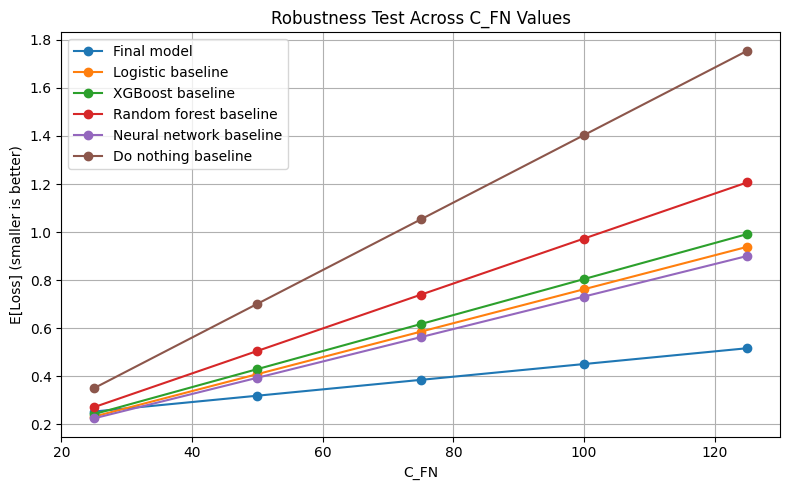

In [ ]:
import matplotlib.pyplot as plt

# Set x-axis
x = robustness_table["C_FN"]

# Columns to plot (everything except C_FN)
model_cols = [
    "Final model",
    "Logistic baseline",
    "XGBoost baseline",
    "Random forest baseline",
    "Neural network baseline",
    "Do nothing baseline",
]

plt.figure(figsize=(8, 5))

for col in model_cols:
    plt.plot(x, robustness_table[col], marker="o", label=col)

plt.xlabel("C_FN")
plt.ylabel("E[Loss] (smaller is better)")
plt.title("Robustness Test Across C_FN Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Performance Robustness Analysis:
Although we fixed C_FN = 75 for our official objective function, in practice, the estimate for C_FN may be inexact. In this section, we verify how robust our model is to perturbations in C_FN.

In the above figure, we graph each model's E[Loss] in the C_FN range [25, 125].

Observations:
- When C_FN is very low (25), our final XGBoost model is comparable with other baseline models, yet still competitive.
- When C_FN is moderately low, medium, or high-valued, our final XGBoost model strictly outperforms all baseline models by a significant margin.
- In all cases, all models strictly outperform the "do nothing" strategy by a significant margin.

We conclude that our model is robust to deviations in C_FN.

# GLOBAL SHAP ANALYSIS
We will now conduct global SHAP feature analysis. Because of the rarity of positive predictions, which may hide the importance of certain features when it comes to predicting fraud, our background distribution will be a 50-50 split of the following 2 classes:
- Training distribution conditioned on the model predicting 1
- Training distribution conditioned on the model predicting 0

Our explanatory dataset will be similarly distributed.

In [ ]:
import numpy as np
import pandas as pd
import shap

y_train_prob = model.predict(dtrain)
y_train_pred = (y_train_prob >= best_threshold).astype(int)

# indices for each prediction class
idx_0 = np.where(y_train_pred == 0)[0]
idx_1 = np.where(y_train_pred == 1)[0]

# background distribution
bg_idx = np.concatenate([
    np.random.choice(idx_0, size=1000, replace=False),
    np.random.choice(idx_1, size=1000, replace=False),
])

bg = X_train_full.iloc[bg_idx]

# explanatory set
explain_idx = np.concatenate([
    np.random.choice(idx_0, size=2500, replace=False),
    np.random.choice(idx_1, size=2500, replace=False),
])

X_explain = X_train_full.iloc[explain_idx]

# SHAP
explainer = shap.TreeExplainer(model, data=bg, model_output="raw")
sv = explainer.shap_values(X_explain)

 97%|=================== | 4848/5000 [00:32<00:01]       

In [ ]:
# global SHAP
global_shap = pd.Series(np.mean(np.abs(sv), axis=0), index=X_explain.columns)
global_shap = global_shap.sort_values(ascending=False)

print(global_shap)
print("Median global SHAP: " + str(global_shap.median()))

cat__device_os_windows                         0.503332
cat__housing_status_BEBCBB                     0.457835
remainder__phone_home_valid                    0.367652
remainder__name_email_similarity               0.342376
remainder__has_other_cards                     0.302957
remainder__keep_alive_session                  0.293916
remainder__prev_address_months_count           0.271986
remainder__current_address_months_count        0.263243
remainder__income                              0.252172
remainder__email_is_free                       0.236422
remainder__bank_branch_count_8w                0.152512
remainder__credit_risk_score                   0.149605
remainder__customer_age                        0.144954
remainder__intended_balcon_amount              0.140616
remainder__velocity_4w                         0.138733
remainder__bank_months_count                   0.137041
remainder__date_of_birth_distinct_emails_4w    0.118332
remainder__days_since_request                  0

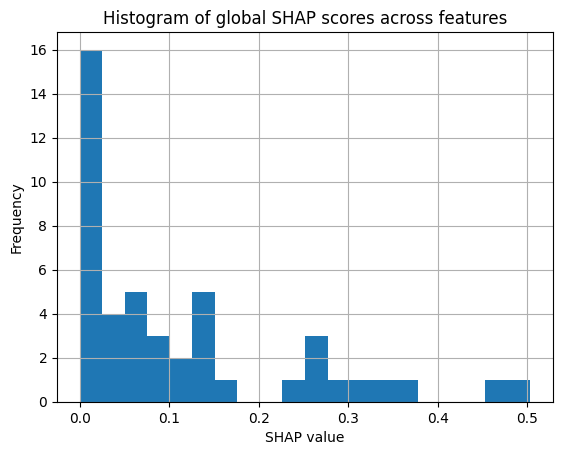

In [ ]:
# create a histogram for global_shap
import matplotlib.pyplot as plt

global_shap.hist(bins=20)
plt.xlabel("SHAP value")
plt.ylabel("Frequency")
plt.title("Histogram of global SHAP scores across features")
plt.show()

## Observations:
- Global SHAP values exhibit a Pareto-like heavy-tailed distribution, suggesting that the number of strongly dominant features the model utilizes to distinguish fraud from non-fraud is limited, with most features providing finer marginal contributions.
- As previously corroborated by our findings in Exploratory_Data_Analysis.ipynb's feature coefficient analysis, our SHAP analysis further suggests that cat__device_os_windows is a highly important feature for predicting fraud.
- As previously corroborated by our findings in Exploratory_Data_Analysis.ipynb's heat map analysis, our SHAP analysis suggests that cat__housing_status_BEBCBB is a highly important feature for predicting fraud.

We note that the following features' global SHAPs are less than 1% of the median global SHAP of all features:
```
cat__source_TELEAPP                            0.000086
cat__employment_status_CG                      0.000000
cat__payment_type_AD                           0.000000
cat__payment_type_AE                           0.000000
cat__housing_status_BG                         0.000000
```
Our global SHAP analysis provides strong evidence that these are not important features for fraud detection in this setting. They present strong candidates for feature pruning in future refinements of the model in order to reduce noise during feature subsampling at training time. 4/5 of these features have an empirical global SHAP score of 0.

In [7]:
print("TELEAPP prevalence:", (X_train_full["cat__source_TELEAPP"] == 1).sum()/len(X_train_full))
print("CG prevalence:", (X_train_full["cat__employment_status_CG"] == 1).sum()/len(X_train_full))
print("AD prevalence:", (X_train_full["cat__payment_type_AD"] == 1).sum()/len(X_train_full))
print("AE prevalence:", (X_train_full["cat__payment_type_AE"] == 1).sum()/len(X_train_full))
print("BG prevalence:", (X_train_full["cat__housing_status_BG"] == 1).sum()/len(X_train_full))

TELEAPP prevalence: 0.00721645205153782
CG prevalence: 0.00046793100281890694
AD prevalence: 0.12460549768613151
AE prevalence: 0.0003119540018792713
BG prevalence: 0.00027924914684354126


As an aside, it may be tempting to assume on a mechanistic level that all 5 candidate features for pruning have negligible causal relationships with the likelihood of fraud. However, it must be pointed out that four of these features (cat__source_TELEAPP, cat__employment_status_CG, cat__payment_type_AE, cat__housing_status_BG) are incredibly rare. Thus, it could very well be the case that their presences have effects, but those effects are washed out in the global SHAP analysis due to how rarely these features appear. To address this, we explore whether or not the conditional probability of fraud is meaningfully affected by the presences of these pruning candidate features.

We will conduct 5 two-proportion hypothesis tests (one for each feature) with Holm-Bonferroni with alpha = 0.05.


In [29]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

def conduct_test(col_name):
  """
  Conducts a two-sided, two-proportion z-test and returns the p-value
  """
  one_index = (X_train_full[col_name] == 1).to_numpy()
  fraud_bool_1 = y_train_full[one_index]
  fraud_bool_0 = y_train_full[~one_index]

  x1 = fraud_bool_1.sum()
  x2 = fraud_bool_0.sum()
  n1 = len(fraud_bool_1)
  n2 = len(fraud_bool_0)

  count = [x1, x2]
  nobs = [n1, n2]

  stat, pval = proportions_ztest(count, nobs, alternative='two-sided')

  return pval

# conduct the 5 tests
pvals = []
col_names = ["cat__source_TELEAPP", "cat__employment_status_CG", "cat__payment_type_AD", "cat__payment_type_AE", "cat__housing_status_BG"]
for col_name in col_names:
  pvals.append(conduct_test(col_name))

rejected, _,_,_ = multipletests(pvals, alpha=0.05, method='holm')

print("We conclude the following features change the likelihood of fraud:")
for i in range(len(rejected)):
  if rejected[i]:
    print(col_names[i], "p-value:", pvals[i], "Conditional probability of fraud:", (y_train_full[X_train_full[col_names[i]] == 1]).mean())

print("")
print("Population probability of fraud:", y_train_full.mean())

We conclude the following features change the likelihood of fraud:
cat__source_TELEAPP p-value: 0.0053403571423002475 Conditional probability of fraud: 0.013944570332926617

Population probability of fraud: 0.010252972053701372


We conclude that cat__source_TELEAPP indeed changes the conditional probability of fraud. Its limited impact in the global SHAP analysis can be attributed to its rarity and perhaps the modesty of its effect when it does appear. Our suggestion to consider pruning it still holds; its benefits do not clearly outweigh the noise it introduces into feature subsampling during training.